In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from bilby.gw.conversion import lambda_1_lambda_2_to_lambda_tilde, lambda_1_lambda_2_to_delta_lambda_tilde, lambda_tilde_delta_lambda_tilde_to_lambda_1_lambda_2

In [ ]:
narrow_df = pd.read_csv("../../events/gw/gw_params_narrow.dat", sep=" ")
events = pd.read_csv("events.dat", sep=" ")
events_old = pd.read_csv("events_old.dat", sep=" ")
events["mass_ratio"] = events["mass_2"] / events["mass_1"]

events_ETL = pd.read_csv("../narrow_ETL/events.dat", sep=' ')

In [3]:
n_coll = np.sum(events["prompt_collapse"] ==1 )
n_tot = events.shape[0]
pop_coll_share = np.sum(narrow_df["prompt_collapse"]==1)/narrow_df.shape[0]

print(f"Prompt collapse: {n_coll}/{n_tot}, {n_coll/n_tot:.3f}, ", pop_coll_share)

Prompt collapse: 4/46, 0.087,  0.12467130703789636


In [4]:
log10_mej_wind = events["log10_mej_wind"]
zeta = 10**(events["log10_mej_wind"] - events["log10_mdisk"])

print("wind quantile: ", np.quantile(log10_mej_wind, 0.05))
print("zeta quantile: ", np.quantile(zeta, 0.05))

wind quantile:  -1.9202720945190834
zeta quantile:  0.11709860528264092


In [5]:
print("SNR min max: ", np.min(events["snr"]), np.max(events["snr"]))

SNR min max:  12.285 262.141


In [6]:
events["log10_mej_wind"].min()

np.float64(-2.658515778987854)

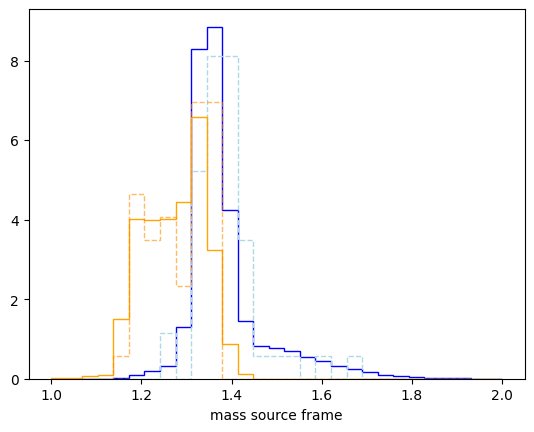

In [7]:
bins = np.linspace(1, 2, 30)

plt.hist(narrow_df["mass_1_source"], bins=bins, density=True, histtype="step", color="blue")
plt.hist(events.loc[:, "mass_1_source"], bins=bins, density=True, histtype="step", color="lightblue", linestyle="dashed")

plt.hist(narrow_df["mass_2_source"], bins=bins, density=True, color="orange", histtype="step")
plt.hist(events.loc[:, "mass_2_source"], bins=bins, density=True, histtype="step", alpha=0.6, color="darkorange", linestyle="dashed")


plt.xlabel("mass source frame")
plt.show()

In [8]:
print(events["chi_1"].max(), events["chi_2"].max())

0.0407806052343095 0.0796186112245692


In [11]:
print(events["mass_ratio"].min(), events["mass_ratio"].max())

0.7258205335293277 0.9954264424538257


In [12]:
print(events["luminosity_distance"].min(), events["luminosity_distance"].max())

277.7217813608225 2772.4172622538445


(array([34., 18., 13.,  8.,  6.,  3.,  0.,  2.,  0.,  1.]),
 array([ 13.101 ,  35.6545,  58.208 ,  80.7615, 103.315 , 125.8685,
        148.422 , 170.9755, 193.529 , 216.0825, 238.636 ]),
 [<matplotlib.patches.Polygon at 0x7fa6b825a5d0>])

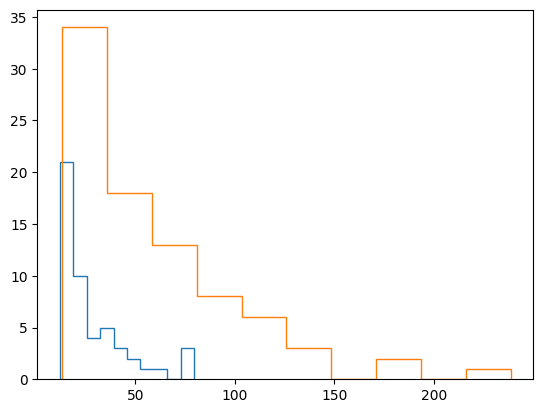

In [5]:
plt.hist(events["snr"], histtype="step")
plt.hist(events_ETL["snr"], histtype="step")

In [9]:
events_ETL["snr"].max()

np.float64(238.636)

In [10]:
events["snr"].max()

np.float64(79.506)